## Interactive Bayesian Optimization (w/UCB Acquisition) for Function 7

Note: This code recommends the next point based on historical data.

Submit the recommended point to the Capstone project portal, obtain the output, then update `input.npy` and `output.npy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
# from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel
from scipy.stats import norm
import os

In [2]:
# Load and check initial data

# INPUT file path
X_init = np.load(r"initial_data\function_7\initial_inputs.npy")
# INPUT file path
y_init = np.load(r"initial_data\function_7\initial_outputs.npy")
print(X_init)
print(y_init)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [3]:
# 1. Configuration

# INPUT dimensionality
dim = 6
len_init = len(X_init)

# Bounds for each dimension
bounds = np.array([[0, 1]] * dim)

# Number of candidate points
n_candidates = 1000

rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
np.random.seed(23)

# INPUT file storing historical inputs 6D array (n, dim)
input_file = r"initial_data\function_7\inputs.npy"

# INPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_7\outputs.npy"

In [4]:
# 2. Helper functions

# Load historical data from input.npy and output.npy
def load_data():
    if os.path.exists(input_file) and os.path.exists(output_file):
        X = np.load(input_file)
        y = np.load(output_file)
        # ensure dimensions match
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"input.npy and output.npy mismatch: {X.shape[0]} vs {y.shape[0]}")
        return X, y
    else:
        print("Will load initial data")
        X = X_init
        y = y_init
        return X, y

# Save historical data to input.npy and output.npy
def save_data(X, y):
    np.save(input_file, X)
    np.save(output_file, y)

# Upper Confidence Bound (UCB) acquisition function
def ucb_acquisition(x_cand, model, beta):
    post_mean, post_std = model.predict(x_cand, return_std = True)
    # avoid zero standard deviation
    post_std = np.maximum(post_std, 1e-9)
    return post_mean + beta * post_std

# Recommend the next point to evaluate
def suggest_next_point(X, y, bounds, n_candidates, beta):
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = 'fixed')
    model = GaussianProcessRegressor(kernel = kernel, alpha = noise_assumption)
    model.fit(X, y)
    # Generate candidate points
    candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size = (n_candidates, dim))
    ucb_values = ucb_acquisition(candidates, model, beta)
    next_idx = np.argmax(ucb_values)
    x_next = candidates[next_idx]
    return x_next

# Plot optimization progress
def plot_progress(X, y, beta):
    best_so_far = np.maximum.accumulate(y)
    plt.figure(figsize = (8, 4))
    plt.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o', markersize = 4)
    plt.xlabel('Number of evaluations')
    plt.ylabel('Best Output found so far')
    plt.title('Optimization Progress (UCB, β={})'.format(beta, beta))
    plt.grid(True)
    plt.show()

# Convert an integer into its ordinal string
def ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

Will load initial data
Loaded 30 points
Current best output: 1.364968


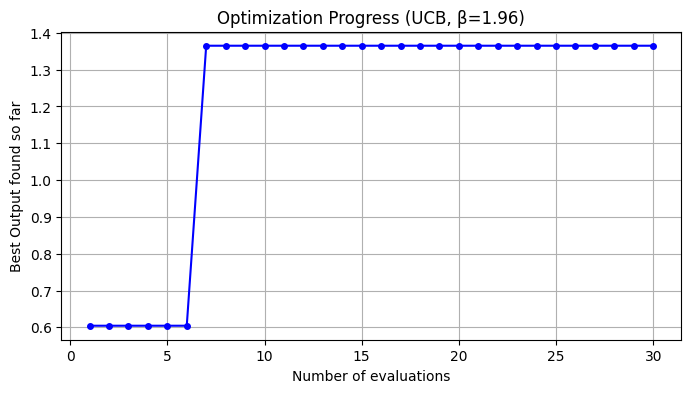

In [5]:
# 3. Load historical data and view current status
X, y = load_data()
print(f"Loaded {len(X)} points")

if len(y) > 0:
    print(f"Current best output: {np.max(y):.6f}")
    plot_progress(X, y, beta)
else:
    print("Please load initial data")

In [6]:
# 4. Recommend the next point to submit
x_next = suggest_next_point(X, y, bounds, n_candidates, beta)

submit_next = len(X) - len_init + 1

print(f"The {ordinal(submit_next)} recommended input point:")
print(np.round(x_next, 6))
print("-".join(map(str, np.round(x_next, 6))))

The 1st recommended input point:
[0.076417 0.116527 0.834244 0.226059 0.026976 0.527452]
0.076417-0.116527-0.834244-0.226059-0.026976-0.527452


In [ ]:
# 5. After obtaining the output from Capstone project portal, update the historical data

# Please manually enter the output value returned by Capstone project portal
y_new = float(input("Enter the output value returned by Capstone project portal: "))

# Append the new point to history
X = np.vstack([X, x_next])
y = np.append(y, y_new)

# Save updated data
save_data(X, y)
print("Historical data updated.")
print(f"There are {len(X_hist)} points, and current best output: {np.max(y_hist):.6f}")

plot_progress(X, y)